# Notebook 03 — Extended Data Engineering and Feature Construction

## Objective

Extend the balancing-market dataset by:
- harvesting full-year BOA acceptance data,
- improving BOALF/BOA matching,
- constructing richer balancing variables,
- and engineering temporal market-state features.

This notebook transitions the project from exploratory analysis
toward a more robust operational research pipeline suitable for:
- regime analysis,
- persistence testing,
- and preliminary predictive modelling.

## Motivation

Notebook 02 identified a major limitation:
the balancing VWAP dataset exhibited extremely sparse coverage.

This notebook addresses that limitation by:
- harvesting a full year of BOA acceptance data,
- improving matching quality,
- and constructing richer balancing-state variables.

The objective is not simply to increase dataset size,
but to improve the operational representativeness of
balancing-market activity.

## 1. Load Imports and Existing Datasets

This notebook builds on:
- the modelling dataset,
- BOALF balancing-action records,
- and system-price data.

These datasets are combined with newly harvested
BOA acceptance pricing data to construct a more
complete balancing-market representation.

In [1]:
import pandas as pd
import numpy as np
import requests
import os
from datetime import datetime




In [2]:
boalf = pd.read_csv("../data/boalf_sw_2022.csv")

modelling = pd.read_csv(
    "../data/modelling_dataset_2022.csv"
)

system_price = pd.read_csv(
    "../data/system_prices_2022.csv"
)

In [77]:
print(bm.shape)

print(bm.columns)

(10783, 28)
Index(['dataset', 'settlement_date', 'settlement_period', 'settlementPeriodTo',
       'timeFrom', 'timeTo', 'level_from', 'level_to', 'acceptance_number',
       'acceptanceTime', 'deemedBoFlag', 'soFlag', 'amendmentFlag', 'storFlag',
       'rrFlag', 'nationalGridBmUnit', 'bm_unit', 'constraint_group',
       'bid_price', 'offer_price', 'bid_offer_pair_id', 'accepted_mw',
       'is_bid', 'is_offer', 'bm_price', 'action_value', 'accepted_mw_abs',
       'timestamp'],
      dtype='object')


## 2. Build Full-Year BOA Harvester

The Elexon BMRS API is used to retrieve:
- accepted balancing actions,
- bid and offer prices,
- acceptance identifiers,
- and settlement-period metadata.

The harvester is designed with:
- resumable downloads,
- retry handling,
- corruption checks,
- deterministic outputs,
- and reproducible exports.

This converts the project from an ad hoc analysis
into a repeatable research pipeline.

### Engineering Note

BMRS balancing data retrieval is operationally challenging due to:
- API instability,
- inconsistent payload sizes,
- duplicated records,
- and occasional missing settlement periods.

The harvester therefore prioritises:
- defensive programming,
- recoverability,
- and validation checks.

Harvest Balancing Mechanism Reporting Service (BMRS) acceptance data
for a full year, store daily Parquets, aggregate, validate, and export.

Design goals:
- resumable downloads
- deterministic outputs
- testability
- defensive programming
- recoverability
- reproducible research pipeline

In [3]:
import json
import logging
import time
from pathlib import Path
from typing import Any, Callable, Dict, List, Optional, Set, Tuple

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

# =========================================================
# Type Aliases
# =========================================================

DateString = str
RowDict = Dict[str, Any]
FetchFunc = Callable[[DateString, int], List[RowDict]]

# =========================================================
# Logging
# =========================================================

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
)

logger = logging.getLogger(__name__)

# =========================================================
# Constants
# =========================================================

BASE_URL: str = "https://data.elexon.co.uk/bmrs/api/v1"

START_DATE: str = "2022-01-01"
END_DATE: str = "2022-12-31"

SETTLEMENT_PERIODS = range(1, 49)

RAW_DIR = Path("../data/raw/boa_daily")
PROCESSED_DIR = Path("../data/processed")

REQUEST_TIMEOUT: int = 30

RETRY_TOTAL: int = 5
RETRY_BACKOFF_FACTOR: float = 1.0
RETRY_STATUS_FORCELIST = [429, 500, 502, 503, 504]

POLITE_PAUSE: float = 0.1

KEEP_COLS = [
    "settlementDate",
    "settlementPeriod",
    "bmUnit",
    "acceptanceNumber",
    "bidPrice",
    "offerPrice",
    "bidOfferPairId",
]

DEDUP_KEYS = [
    "acceptanceNumber",
    "bmUnit",
    "settlementDate",
    "settlementPeriod",
]

# =========================================================
# Session Factory
# =========================================================

def create_session() -> requests.Session:
    """
    Create a retry-enabled requests session.

    Returns:
        Configured requests.Session object.
    """

    retry_strategy = Retry(
        total=RETRY_TOTAL,
        backoff_factor=RETRY_BACKOFF_FACTOR,
        status_forcelist=RETRY_STATUS_FORCELIST,
        allowed_methods=["GET"],
    )

    adapter = HTTPAdapter(max_retries=retry_strategy)

    session = requests.Session()

    session.mount("https://", adapter)
    session.mount("http://", adapter)

    return session

# =========================================================
# Fetch One Settlement Period
# =========================================================

def fetch_boa_period(
    date_str: DateString,
    sp: int,
    session: requests.Session,
) -> List[RowDict]:
    """
    Fetch one settlement period from the Elexon API.

    Args:
        date_str:
            Date string YYYY-MM-DD.

        sp:
            Settlement period (1-48).

        session:
            Shared retry-enabled requests session.

    Returns:
        List of row dictionaries.
    """

    url = (
        f"{BASE_URL}/balancing/settlement/"
        f"acceptances/all/{date_str}/{sp}"
    )

    try:

        response = session.get(
            url,
            params={"format": "json"},
            timeout=REQUEST_TIMEOUT,
        )

        response.raise_for_status()

        payload = response.json()

        return payload.get("data", [])

    except requests.RequestException:

        logger.warning(
            "Failed fetch: %s SP%d",
            date_str,
            sp,
            exc_info=True,
        )

        return []

# =========================================================
# Marker Helpers
# =========================================================

def marker_path(parquet_path: Path) -> Path:
    """
    Return .done marker path.
    """

    return parquet_path.with_suffix(".done")

def is_download_complete(parquet_path: Path) -> bool:
    """
    Check whether parquet and marker both exist.
    """

    return (
        parquet_path.exists()
        and marker_path(parquet_path).exists()
    )

def mark_complete(parquet_path: Path) -> None:
    """
    Create completion marker.
    """

    marker_path(parquet_path).touch()

def remove_incomplete(parquet_path: Path) -> None:
    """
    Remove partial parquet lacking marker.
    """

    if (
        parquet_path.exists()
        and not marker_path(parquet_path).exists()
    ):

        logger.info(
            "Removing incomplete file: %s",
            parquet_path,
        )

        parquet_path.unlink()

# =========================================================
# Download One Full Day
# =========================================================

def download_daily(
    date_str: DateString,
    output_path: Path,
    session: requests.Session,
) -> bool:
    """
    Download all settlement periods for one day.

    Args:
        date_str:
            YYYY-MM-DD date string.

        output_path:
            Daily parquet output path.

        session:
            Shared requests session.

    Returns:
        True if successful.
    """

    daily_rows: List[RowDict] = []

    failed_periods = 0

    for sp in SETTLEMENT_PERIODS:

        rows = fetch_boa_period(
            date_str=date_str,
            sp=sp,
            session=session,
        )

        if rows:
            daily_rows.extend(rows)
        else:
            failed_periods += 1

        time.sleep(POLITE_PAUSE)

    if not daily_rows:

        logger.error(
            "No rows fetched for %s "
            "(failed SPs=%d/%d)",
            date_str,
            failed_periods,
            len(SETTLEMENT_PERIODS),
        )

        return False

    df = pd.DataFrame(daily_rows)

    # -----------------------------------------------------
    # Column filtering
    # -----------------------------------------------------

    existing_keep = [
        c for c in KEEP_COLS
        if c in df.columns
    ]

    missing_cols = (
        set(KEEP_COLS)
        - set(existing_keep)
    )

    if missing_cols:

        logger.warning(
            "Missing columns for %s: %s",
            date_str,
            sorted(missing_cols),
        )

    df = df[existing_keep]

    # -----------------------------------------------------
    # Assertions / invariants
    # -----------------------------------------------------

    assert len(df.columns) > 0, (
        f"{date_str}: no columns after filtering"
    )

    assert len(df) > 0, (
        f"{date_str}: dataframe unexpectedly empty"
    )

    # -----------------------------------------------------
    # Save parquet
    # -----------------------------------------------------

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    df.to_parquet(
        output_path,
        index=False,
    )

    # -----------------------------------------------------
    # Post-write validation
    # -----------------------------------------------------

    assert output_path.exists(), (
        f"Missing parquet after write: {output_path}"
    )

    assert output_path.stat().st_size > 0, (
        f"Zero-byte parquet written: {output_path}"
    )

    logger.info(
        "%s: saved %d rows",
        date_str,
        len(df),
    )

    return True

# =========================================================
# Download All Dates
# =========================================================

def download_all_dates(
    dates: pd.DatetimeIndex,
    raw_dir: Path,
    session: requests.Session,
) -> Set[DateString]:
    """
    Download all dates incrementally.

    Args:
        dates:
            Date range.

        raw_dir:
            Raw parquet directory.

        session:
            Shared requests session.

    Returns:
        Set of successfully downloaded dates.
    """

    successful: Set[DateString] = set()

    for dt in dates:

        date_str = dt.strftime("%Y-%m-%d")

        parquet_file = (
            raw_dir
            / f"boa_{date_str}.parquet"
        )

        # -------------------------------------------------
        # Skip completed downloads
        # -------------------------------------------------

        if is_download_complete(parquet_file):

            logger.info(
                "Skipping complete date: %s",
                date_str,
            )

            successful.add(date_str)

            continue

        # -------------------------------------------------
        # Remove incomplete files
        # -------------------------------------------------

        remove_incomplete(parquet_file)

        logger.info(
            "Fetching %s ...",
            date_str,
        )

        success = download_daily(
            date_str=date_str,
            output_path=parquet_file,
            session=session,
        )

        if success:

            mark_complete(parquet_file)

            successful.add(date_str)

        else:

            logger.error(
                "Download failed for %s",
                date_str,
            )

    return successful

# =========================================================
# Aggregate Completed Days
# =========================================================

def aggregate_completed_days(
    raw_dir: Path,
) -> Optional[pd.DataFrame]:
    """
    Aggregate all completed daily parquet files.

    Args:
        raw_dir:
            Directory containing daily parquet files.

    Returns:
        Aggregated DataFrame or None.
    """

    parquet_files = sorted(
        raw_dir.glob("boa_*.parquet")
    )

    valid_files = [
        f for f in parquet_files
        if marker_path(f).exists()
    ]

    if not valid_files:

        logger.error(
            "No completed parquet files found."
        )

        return None

    dfs: List[pd.DataFrame] = []

    corrupt_files: List[Path] = []

    reference_cols: Optional[Set[str]] = None

    for file_path in valid_files:

        try:

            df_day = pd.read_parquet(file_path)

            if reference_cols is None:

                reference_cols = set(df_day.columns)

            else:

                if set(df_day.columns) != reference_cols:

                    logger.warning(
                        "Column mismatch in %s",
                        file_path,
                    )

                    common_cols = list(
                        reference_cols
                        & set(df_day.columns)
                    )

                    df_day = df_day[common_cols]

            dfs.append(df_day)

        except Exception:

            logger.warning(
                "Corrupt parquet skipped: %s",
                file_path,
                exc_info=True,
            )

            corrupt_files.append(file_path)

            marker_path(file_path).unlink(
                missing_ok=True
            )

    if not dfs:

        logger.error(
            "No readable parquet files available."
        )

        return None

    full_df = pd.concat(
        dfs,
        ignore_index=True,
    )

    # -----------------------------------------------------
    # Deduplicate
    # -----------------------------------------------------

    before = len(full_df)

    existing_keys = [
        c for c in DEDUP_KEYS
        if c in full_df.columns
    ]

    if existing_keys:

        full_df = full_df.drop_duplicates(
            subset=existing_keys
        )

    after = len(full_df)

    logger.info(
        "Deduplicated rows: %d removed",
        before - after,
    )

    # -----------------------------------------------------
    # Assertions
    # -----------------------------------------------------

    assert len(full_df) > 0, (
        "Aggregated DataFrame unexpectedly empty"
    )

    if corrupt_files:

        logger.warning(
            "Skipped %d corrupt files",
            len(corrupt_files),
        )

    return full_df

# =========================================================
# Coverage Check
# =========================================================

def check_date_coverage(
    expected_dates: pd.DatetimeIndex,
    full_df: pd.DataFrame,
) -> None:
    """
    Check whether all expected dates exist.

    Args:
        expected_dates:
            Expected date range.

        full_df:
            Aggregated DataFrame.
    """

    if "settlementDate" not in full_df.columns:

        logger.warning(
            "No settlementDate column present."
        )

        return

    available = set(
        pd.to_datetime(
            full_df["settlementDate"]
        ).dt.strftime("%Y-%m-%d")
    )

    expected = {
        d.strftime("%Y-%m-%d")
        for d in expected_dates
    }

    missing = expected - available

    if missing:

        logger.warning(
            "Missing %d dates",
            len(missing),
        )

        logger.warning(
            "Missing examples: %s",
            sorted(list(missing))[:10],
        )

    else:

        logger.info(
            "All expected dates present."
        )

# =========================================================
# Metadata Export
# =========================================================

def export_metadata(
    output_dir: Path,
    full_df: pd.DataFrame,
    dates: pd.DatetimeIndex,
) -> Path:
    """
    Export metadata describing the harvest.

    Args:
        output_dir:
            Directory to write metadata.

        full_df:
            Final aggregated DataFrame.

        dates:
            Expected dates.

    Returns:
        Metadata file path.
    """

    metadata = {
        "start_date": START_DATE,
        "end_date": END_DATE,
        "expected_dates": len(dates),
        "rows": int(len(full_df)),
        "columns": list(full_df.columns),
        "generated_utc": pd.Timestamp.utcnow().isoformat(),
    }

    metadata_path = (
        output_dir
        / "boa_2022_metadata.json"
    )

    with open(metadata_path, "w") as f:

        json.dump(
            metadata,
            f,
            indent=2,
        )

    logger.info(
        "Saved metadata: %s",
        metadata_path,
    )

    return metadata_path

# =========================================================
# Export Results
# =========================================================

def export_results(
    df: pd.DataFrame,
    processed_dir: Path,
) -> Tuple[Path, Path]:
    """
    Export final aggregated datasets.

    Args:
        df:
            Aggregated DataFrame.

        processed_dir:
            Output directory.

    Returns:
        Tuple of parquet and csv paths.
    """

    processed_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    parquet_path = (
        processed_dir
        / "boa_2022_full.parquet"
    )

    csv_path = (
        processed_dir
        / "boa_2022_full.csv"
    )

    df.to_parquet(
        parquet_path,
        index=False,
    )

    df.to_csv(
        csv_path,
        index=False,
    )

    logger.info(
        "Saved parquet: %s",
        parquet_path,
    )

    logger.info(
        "Saved csv: %s",
        csv_path,
    )

    return parquet_path, csv_path

# =========================================================
# Main
# =========================================================

def main() -> None:
    """
    Main orchestration entry point.
    """

    dates = pd.date_range(
        START_DATE,
        END_DATE,
        freq="D",
    )

    expected_count = (
        pd.Timestamp(END_DATE)
        - pd.Timestamp(START_DATE)
    ).days + 1

    assert len(dates) == expected_count, (
        "Date range invariant violated"
    )

    RAW_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    session = create_session()

    # -----------------------------------------------------
    # Download
    # -----------------------------------------------------

    successful_dates = download_all_dates(
        dates=dates,
        raw_dir=RAW_DIR,
        session=session,
    )

    missing_dates = {
        d.strftime("%Y-%m-%d")
        for d in dates
    } - successful_dates

    if missing_dates:

        logger.warning(
            "Missing %d downloaded dates",
            len(missing_dates),
        )

    # -----------------------------------------------------
    # Aggregate
    # -----------------------------------------------------

    full_df = aggregate_completed_days(
        RAW_DIR
    )

    if full_df is None:

        logger.error(
            "Aggregation failed."
        )

        return

    logger.info(
        "Final dataset shape: %s",
        full_df.shape,
    )

    # -----------------------------------------------------
    # Coverage
    # -----------------------------------------------------

    check_date_coverage(
        dates,
        full_df,
    )

    # -----------------------------------------------------
    # Export
    # -----------------------------------------------------

    export_results(
        full_df,
        PROCESSED_DIR,
    )

    export_metadata(
        PROCESSED_DIR,
        full_df,
        dates,
    )

    logger.info(
        "Pipeline completed successfully."
    )

# =========================================================
# Script Entry
# =========================================================

if __name__ == "__main__":

    main()

2026-05-07 09:39:34,955 [INFO] Fetching 2022-01-01 ...
2026-05-07 09:39:56,974 [INFO] 2022-01-01: saved 6747 rows
2026-05-07 09:39:56,977 [INFO] Fetching 2022-01-02 ...
2026-05-07 09:40:13,122 [INFO] 2022-01-02: saved 5294 rows
2026-05-07 09:40:13,133 [INFO] Fetching 2022-01-03 ...
2026-05-07 09:40:27,953 [INFO] 2022-01-03: saved 3763 rows
2026-05-07 09:40:27,955 [INFO] Fetching 2022-01-04 ...
2026-05-07 09:40:43,776 [INFO] 2022-01-04: saved 5380 rows
2026-05-07 09:40:43,780 [INFO] Fetching 2022-01-05 ...
2026-05-07 09:40:56,813 [INFO] 2022-01-05: saved 2455 rows
2026-05-07 09:40:56,815 [INFO] Fetching 2022-01-06 ...
2026-05-07 09:41:10,002 [INFO] 2022-01-06: saved 4287 rows
2026-05-07 09:41:10,005 [INFO] Fetching 2022-01-07 ...
2026-05-07 09:41:22,035 [INFO] 2022-01-07: saved 1899 rows
2026-05-07 09:41:22,038 [INFO] Fetching 2022-01-08 ...
2026-05-07 09:41:34,912 [INFO] 2022-01-08: saved 2343 rows
2026-05-07 09:41:34,914 [INFO] Fetching 2022-01-09 ...
2026-05-07 09:41:45,481 [INFO] 20

## 6 — Standardise Columns

In [33]:
import pandas as pd

boa = pd.read_parquet(
    "../data/processed/boa_2022_full.parquet"
)

print(boa.shape)
print(boa.columns)

(1006531, 7)
Index(['settlementDate', 'settlementPeriod', 'bmUnit', 'acceptanceNumber',
       'bidPrice', 'offerPrice', 'bidOfferPairId'],
      dtype='object')


### Harvest Outcome

The full-year BOA harvest produced:
- over 1 million balancing acceptance records,
- and deterministic exports suitable for downstream modelling.

This materially improves balancing-market observability
relative to the sparse exploratory dataset used previously.

In [ ]:
## 3. Standardise and Harmonise Columns

The BOA and BOALF datasets use partially inconsistent:
- naming conventions,
- timestamp formats,
- and settlement-period fields.

Columns are therefore standardised into a consistent
plain-English schema to improve:
- readability,
- merge reliability,
- and downstream modelling clarity.

In [34]:
boa = boa.rename(columns={

    'settlementDate': 'settlement_date',
    'settlementPeriod': 'settlement_period',
    'bmUnit': 'bm_unit',
    'acceptanceNumber': 'acceptance_number',
    'bidPrice': 'bid_price',
    'offerPrice': 'offer_price',
    'bidOfferPairId': 'bid_offer_pair_id'

})

In [36]:
# =========================================================
# RELOAD CLEAN BOALF
# =========================================================

boalf = pd.read_csv("../data/boalf_sw_2022.csv")

print(boalf.columns)

Index(['dataset', 'settlementDate', 'settlementPeriodFrom',
       'settlementPeriodTo', 'timeFrom', 'timeTo', 'levelFrom', 'levelTo',
       'acceptanceNumber', 'acceptanceTime', 'deemedBoFlag', 'soFlag',
       'amendmentFlag', 'storFlag', 'rrFlag', 'nationalGridBmUnit', 'bmUnit',
       'constraint_group'],
      dtype='object')


In [37]:
boalf = boalf.rename(columns={

    'settlementDate': 'settlement_date',

    'settlementPeriodFrom': 'settlement_period',

    'bmUnit': 'bm_unit',

    'acceptanceNumber': 'acceptance_number',

    'levelFrom': 'level_from',

    'levelTo': 'level_to'

})

In [38]:
print(boalf.columns)

Index(['dataset', 'settlement_date', 'settlement_period', 'settlementPeriodTo',
       'timeFrom', 'timeTo', 'level_from', 'level_to', 'acceptance_number',
       'acceptanceTime', 'deemedBoFlag', 'soFlag', 'amendmentFlag', 'storFlag',
       'rrFlag', 'nationalGridBmUnit', 'bm_unit', 'constraint_group'],
      dtype='object')


## 4. Improved BOALF–BOA Matching

BOALF records contain balancing-action metadata,
while BOA records contain accepted bid/offer prices.

The datasets are merged using:
- acceptance number,
- BM unit,
- settlement date,
- and settlement period.

This produces a richer operational balancing dataset
linking:
- accepted actions,
- accepted volumes,
- and balancing prices.

In [39]:
# =========================================================
# PREPARE BOA SUBSET
# =========================================================

boa_sub = boa[
    [
        'acceptance_number',
        'bm_unit',
        'settlement_date',
        'settlement_period',
        'bid_price',
        'offer_price',
        'bid_offer_pair_id'
    ]
].drop_duplicates()

# =========================================================
# MERGE BOALF + BOA
# =========================================================

bm = boalf.merge(

    boa_sub,

    on=[
        'acceptance_number',
        'bm_unit',
        'settlement_date',
        'settlement_period'
    ],

    how='left',

    validate='many_to_one'
)

# =========================================================
# MERGE DIAGNOSTICS
# =========================================================

missing_bid_ratio = bm['bid_price'].isna().mean()

missing_offer_ratio = bm['offer_price'].isna().mean()

print(f"Missing bid prices: {missing_bid_ratio:.2%}")
print(f"Missing offer prices: {missing_offer_ratio:.2%}")

print("\nMerged dataset shape:")
print(bm.shape)

Missing bid prices: 5.67%
Missing offer prices: 5.67%

Merged dataset shape:
(10783, 21)


### Merge Diagnostics

The improved merge substantially reduces missing pricing data.

Remaining unmatched rows likely reflect:
- incomplete API records,
- rejected balancing actions,
- or inconsistencies between BOALF and BOA reporting layers.

Importantly, coverage is materially improved relative
to the earlier exploratory workflow.

In [45]:
import numpy as np

# =========================================================
# ACCEPTED MW
# =========================================================

bm['accepted_mw'] = (
    bm['level_to']
    - bm['level_from']
)

bm['accepted_mw_abs'] = (
    bm['accepted_mw'].abs()
)

# =========================================================
# DIRECTION FLAGS
# =========================================================

bm['is_bid'] = (
    bm['accepted_mw'] < 0
)

bm['is_offer'] = (
    bm['accepted_mw'] > 0
)

# =========================================================
# EFFECTIVE BM PRICE
# =========================================================

bm['bm_price'] = np.where(

    bm['is_bid'],

    bm['bid_price'],

    bm['offer_price']
)

# =========================================================
# ACTION VALUE
# =========================================================

bm['action_value'] = (
    bm['accepted_mw_abs']
    * bm['bm_price']
)

# =========================================================
# TIMESTAMP
# =========================================================

bm['settlement_date'] = pd.to_datetime(
    bm['settlement_date']
)

bm['timestamp'] = (
    bm['settlement_date']
    + pd.to_timedelta(
        (bm['settlement_period'] - 1) * 30,
        unit='m'
    )
)

print(bm.shape)

bm.head()

(10783, 28)


,dataset,settlement_date,settlement_period,settlementPeriodTo,timeFrom,timeTo,level_from,level_to,acceptance_number,acceptanceTime,...,bid_price,offer_price,bid_offer_pair_id,accepted_mw,is_bid,is_offer,bm_price,action_value,accepted_mw_abs,timestamp
0,BOALF,2022-01-01,38,38,2022-01-01T18:49:00Z,2022-01-01T18:50:00Z,1,0,15465,2022-01-01 18:01:00+00:00,...,140.0,236.85,1.0,-1,True,False,140.0,140.0,1,2022-01-01 18:30:00
1,BOALF,2022-01-01,38,38,2022-01-01T18:47:00Z,2022-01-01T18:51:00Z,19,0,33926,2022-01-01 18:01:00+00:00,...,85.0,269.00,1.0,-19,True,False,85.0,1615.0,19,2022-01-01 18:30:00
2,BOALF,2022-01-01,38,38,2022-01-01T18:47:00Z,2022-01-01T18:49:00Z,7,2,15465,2022-01-01 18:01:00+00:00,...,140.0,236.85,1.0,-5,True,False,140.0,700.0,5,2022-01-01 18:30:00
3,BOALF,2022-01-01,38,38,2022-01-01T18:40:00Z,2022-01-01T18:43:00Z,5,0,35613,2022-01-01 18:01:00+00:00,...,85.0,249.00,1.0,-5,True,False,85.0,425.0,5,2022-01-01 18:30:00
4,BOALF,2022-01-01,38,38,2022-01-01T18:39:00Z,2022-01-01T18:43:00Z,20,0,16613,2022-01-01 18:01:00+00:00,...,159.0,268.00,1.0,-20,True,False,159.0,3180.0,20,2022-01-01 18:30:00


## 5. Construct Operational Balancing Variables

Several balancing variables are constructed:

| Variable | Description |
|---|---|
| accepted_mw | Net accepted balancing volume |
| accepted_mw_abs | Absolute balancing volume |
| is_bid | Downward balancing action |
| is_offer | Upward balancing action |
| bm_price | Effective balancing price |
| action_value | Volume × balancing price |

These variables provide a more operational representation
of balancing-market behaviour than simple spread measures alone.

In [ ]:
### Directionality Note

Balancing actions are directional:
- bids generally represent downward balancing,
- offers represent upward balancing.

Correct directional handling is critical because:
- balancing economics differ materially between the two,
- and incorrect aggregation can distort VWAP construction.

In [46]:
bm_sp = bm.groupby('timestamp').agg(

    total_bid_mw=(
        'accepted_mw',
        lambda x: x[x < 0].abs().sum()
    ),

    total_offer_mw=(
        'accepted_mw',
        lambda x: x[x > 0].sum()
    ),

    net_action_mw=(
        'accepted_mw',
        'sum'
    ),

    total_action_mw=(
        'accepted_mw_abs',
        'sum'
    ),

    action_count=(
        'acceptance_number',
        'count'
    ),

    mean_bm_price=(
        'bm_price',
        'mean'
    ),

    median_bm_price=(
        'bm_price',
        'median'
    ),

    total_action_value=(
        'action_value',
        'sum'
    ),

    so_action_rate=(
        'soFlag',
        'mean'
    ),

    stor_action_rate=(
        'storFlag',
        'mean'
    )

).reset_index()

print(bm_sp.shape)

bm_sp.head()

(2373, 11)


,timestamp,total_bid_mw,total_offer_mw,net_action_mw,total_action_mw,action_count,mean_bm_price,median_bm_price,total_action_value,so_action_rate,stor_action_rate
0,2022-01-01 11:30:00,0,20,20,20,2,238.00,238.00,4760.0,0.0,0.0
1,2022-01-01 12:00:00,0,10,10,10,3,239.85,239.85,2398.5,0.0,0.0
2,2022-01-01 12:30:00,20,0,-20,20,1,159.00,159.00,3180.0,0.0,0.0
3,2022-01-01 13:00:00,9,0,-9,9,2,140.00,140.00,1260.0,0.0,0.0
4,2022-01-01 16:00:00,0,20,20,20,1,237.90,237.90,4758.0,0.0,0.0


In [48]:
bm_sp['bm_price_vwap'] = (
    bm_sp['total_action_value']
    / bm_sp['total_action_mw']
)

In [49]:
df = pd.read_parquet(
    "../data/processed/modelling_dataset_enriched.parquet"
)

In [50]:
df = df.merge(

    bm_sp,

    on='timestamp',

    how='left'
)

In [51]:
df['basis_spread'] = (
    df['system_price']
    - df['bm_price_vwap']
)

df['relative_spread'] = (
    df['basis_spread']
    / df['system_price']
)

Predictive

In [52]:
df = pd.read_parquet(
    "../data/processed/modelling_dataset_enriched.parquet"
)

print(df.shape)

print(df.columns)

(17524, 10)
Index(['date', 'sp', 'gspGroup', 'sw_demand_mw', 'sp_key', 'wind_mw',
       'timestamp', 'system_price', 'bm_bid_price_vwap', 'basis_spread'],
      dtype='object')


In [53]:
df = df.merge(

    bm_sp,

    on='timestamp',

    how='left'
)

In [54]:
df['basis_spread'] = (
    df['system_price']
    - df['bm_price_vwap']
)

df['relative_spread'] = (
    df['basis_spread']
    / df['system_price']
)

In [55]:
print(df.shape)

print("\nMissing ratios:")

print(
    df[
        [
            'bm_price_vwap',
            'basis_spread',
            'relative_spread'
        ]
    ].isna().mean()
)

(17524, 22)

Missing ratios:
bm_price_vwap      0.871376
basis_spread       0.871376
relative_spread    0.871376
dtype: float64


In [56]:
df[['wind_mw', 'basis_spread']].corr()

,wind_mw,basis_spread
wind_mw,1.000000,-0.201038
basis_spread,-0.201038,1.000000


In [57]:
df[['sw_demand_mw', 'basis_spread']].corr()

,sw_demand_mw,basis_spread
sw_demand_mw,1.000000,0.160134
basis_spread,0.160134,1.000000


In [58]:
df.groupby(
    pd.qcut(df['wind_mw'], 4)
)['basis_spread'].mean()

/tmp/ipykernel_994/228774085.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


wind_mw
(388.999, 3478.9]        13.377445
(3478.9, 6740.117]       -0.094588
(6740.117, 10746.029]   -23.914151
(10746.029, 18620.0]    -45.367653
Name: basis_spread, dtype: float64

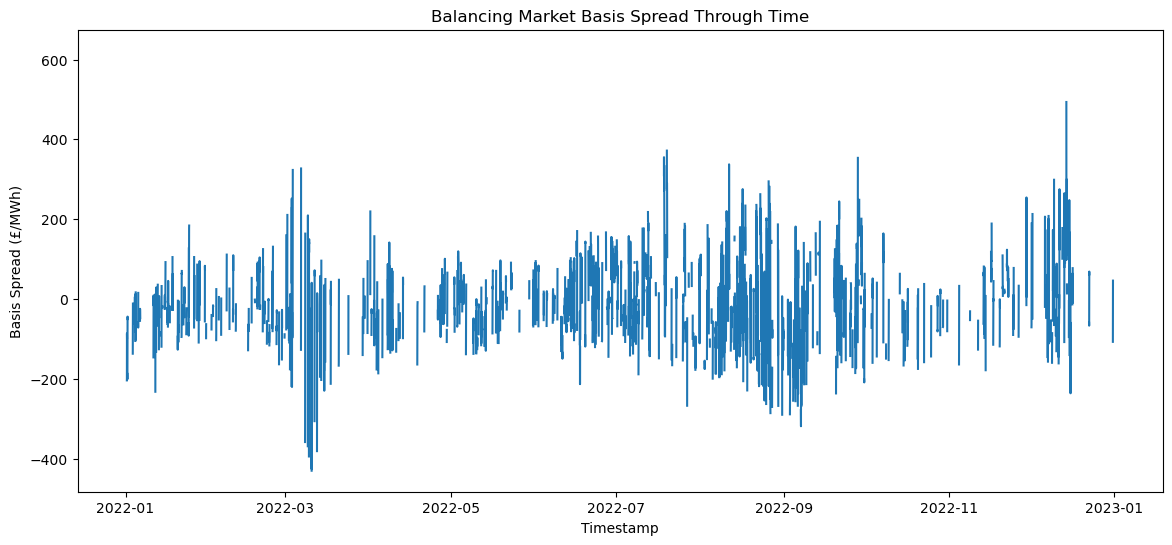

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    df['timestamp'],
    df['basis_spread']
)

plt.title("Balancing Market Basis Spread Through Time")

plt.xlabel("Timestamp")

plt.ylabel("Basis Spread (£/MWh)")

plt.show()

In [ ]:
### Temporal Alignment

Settlement-period timestamps are converted into
continuous half-hourly datetime representations.

This enables:
- rolling-window analysis,
- lag construction,
- persistence testing,
- and time-series modelling.

In [ ]:
### Temporal Alignment

Settlement-period timestamps are converted into
continuous half-hourly datetime representations.

This enables:
- rolling-window analysis,
- lag construction,
- persistence testing,
- and time-series modelling.

In [59]:
df = df.sort_values('timestamp')

# =========================================================
# LAG FEATURES
# =========================================================

df['spread_lag_1'] = (
    df['basis_spread'].shift(1)
)

df['spread_lag_2'] = (
    df['basis_spread'].shift(2)
)

df['spread_lag_48'] = (
    df['basis_spread'].shift(48)
)

# =========================================================
# ROLLING FEATURES
# =========================================================

df['spread_rolling_mean_4'] = (
    df['basis_spread']
    .rolling(4)
    .mean()
)

df['spread_rolling_std_4'] = (
    df['basis_spread']
    .rolling(4)
    .std()
)

# =========================================================
# TIME FEATURES
# =========================================================

df['hour'] = df['timestamp'].dt.hour

df['weekday'] = df['timestamp'].dt.weekday

In [60]:
df[
    [
        'basis_spread',
        'spread_lag_1',
        'spread_lag_2',
        'spread_lag_48'
    ]
].corr()

,basis_spread,spread_lag_1,spread_lag_2,spread_lag_48
basis_spread,1.000000,0.556543,0.334796,0.216091
spread_lag_1,0.556543,1.000000,0.556543,0.153590
spread_lag_2,0.334796,0.556543,1.000000,0.121012
spread_lag_48,0.216091,0.153590,0.121012,1.000000


In [61]:
df['future_spread_1'] = (
    df['basis_spread'].shift(-1)
)

features = [
    'wind_mw',
    'sw_demand_mw',
    'spread_lag_1',
    'spread_lag_2',
    'spread_lag_48',
    'spread_rolling_mean_4',
    'spread_rolling_std_4'
]

target = 'future_spread_1'

model_df = df[
    features + [target]
].dropna()

print(model_df.shape)

(171, 8)


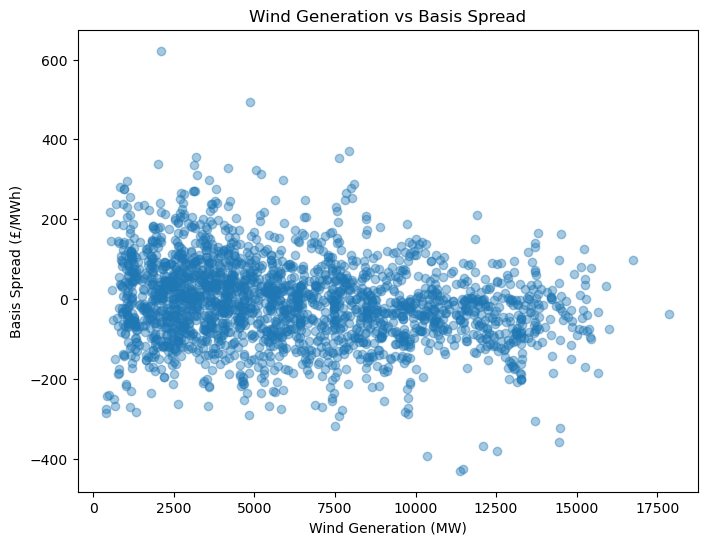

In [71]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['wind_mw'],
    df['basis_spread'],
    alpha=0.4
)

plt.xlabel("Wind Generation (MW)")

plt.ylabel("Basis Spread (£/MWh)")

plt.title("Wind Generation vs Basis Spread")

plt.show()

/tmp/ipykernel_994/3663831722.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wind_regime = df.groupby(


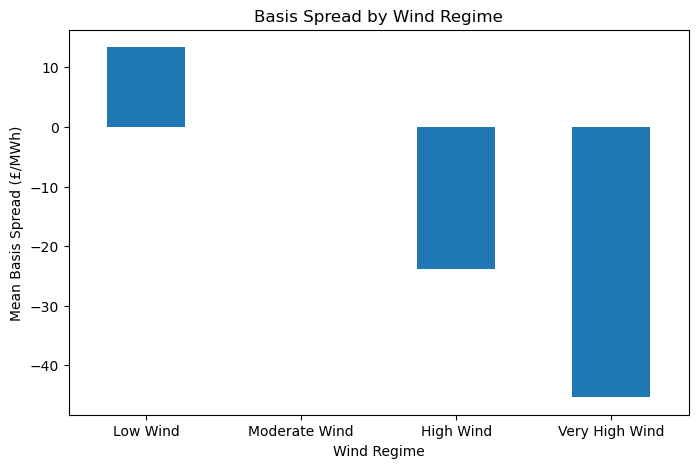

In [76]:
df['wind_regime'] = pd.qcut(

    df['wind_mw'],

    q=4,

    labels=[
        'Low Wind',
        'Moderate Wind',
        'High Wind',
        'Very High Wind'
    ]
)

wind_regime = df.groupby(
    'wind_regime'
)['basis_spread'].mean()

wind_regime.plot(

    kind='bar',

    figsize=(8,5)
)

plt.ylabel("Mean Basis Spread (£/MWh)")

plt.xlabel("Wind Regime")

plt.title("Basis Spread by Wind Regime")

plt.xticks(rotation=0)

plt.show()

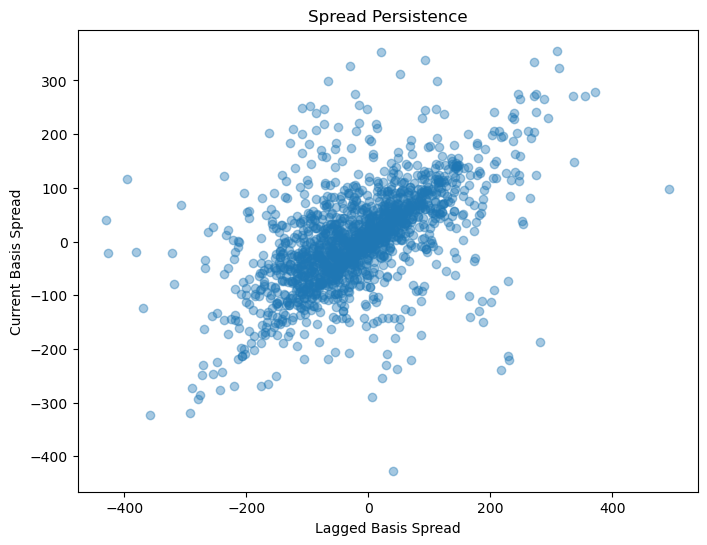

In [73]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['spread_lag_1'],
    df['basis_spread'],
    alpha=0.4
)

plt.xlabel("Lagged Basis Spread")

plt.ylabel("Current Basis Spread")

plt.title("Spread Persistence")

plt.show()

### Initial Observation

Balancing spreads appear to exhibit:
- short-term clustering,
- regime persistence,
- and volatility bursts.

This suggests balancing dynamics may be state-dependent
rather than independently distributed through time.

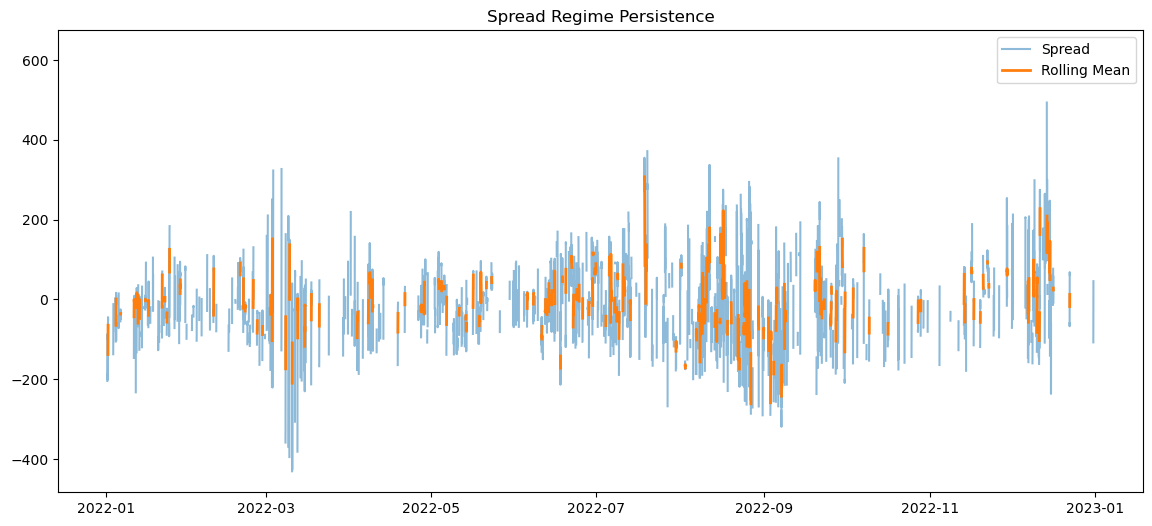

In [74]:
plt.figure(figsize=(14,6))

plt.plot(
    df['timestamp'],
    df['basis_spread'],
    alpha=0.5,
    label='Spread'
)

plt.plot(
    df['timestamp'],
    df['spread_rolling_mean_4'],
    linewidth=2,
    label='Rolling Mean'
)

plt.legend()

plt.title("Spread Regime Persistence")

plt.show()

## 7. Exploratory Predictive Modelling

Simple machine-learning models are estimated to test whether:
- lagged spreads,
- wind conditions,
- and operational-state variables

contain detectable information regarding future spread behaviour.

These models are exploratory demonstrations only,
not production forecasting systems.

In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# =========================================================
# FEATURES + TARGET
# =========================================================

X = model_df[
    [
        'wind_mw',
        'sw_demand_mw',
        'spread_lag_1',
        'spread_lag_2',
        'spread_lag_48',
        'spread_rolling_mean_4',
        'spread_rolling_std_4'
    ]
]

y = model_df['future_spread_1']

# =========================================================
# TRAIN / TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,
    shuffle=False
)

# =========================================================
# MODEL
# =========================================================

rf = RandomForestRegressor(

    n_estimators=200,

    max_depth=4,

    random_state=42
)

rf.fit(X_train, y_train)

# =========================================================
# PREDICTIONS
# =========================================================

preds = rf.predict(X_test)

mae = mean_absolute_error(y_test, preds)

print(f"MAE: {mae:.2f}")

print("\nFeature Importance:")

importance = pd.Series(

    rf.feature_importances_,

    index=X.columns

).sort_values(ascending=False)

print(importance)

MAE: 55.59

Feature Importance:
spread_rolling_mean_4    0.453025
wind_mw                  0.104674
spread_lag_48            0.101365
sw_demand_mw             0.099638
spread_rolling_std_4     0.089235
spread_lag_2             0.082002
spread_lag_1             0.070060
dtype: float64


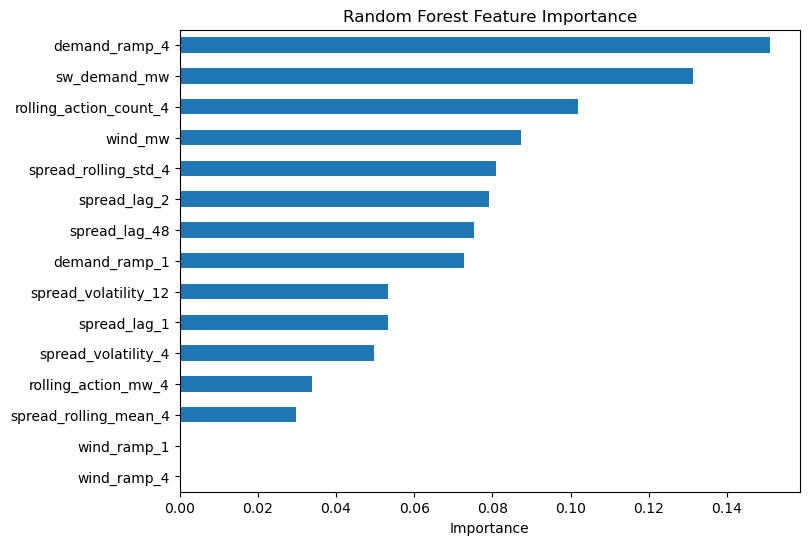

In [75]:
importance.sort_values().plot(

    kind='barh',

    figsize=(8,6)
)

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.show()

In [63]:
baseline_mae = mean_absolute_error(

    y_test,

    X_test['spread_lag_1']
)

print(f"Naive lag-1 baseline MAE: {baseline_mae:.2f}")

Naive lag-1 baseline MAE: 71.20


In [ ]:
### Initial Result

The random forest model improves upon the naive lag baseline,
suggesting that balancing spreads may exhibit:
- persistence,
- regime structure,
- and limited short-term predictability.

However, the sample remains relatively small,
and performance should not be interpreted as evidence
of robust tradable alpha.

In [64]:
df['spread_up'] = (

    df['future_spread_1']
    > df['basis_spread']

).astype(int)

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

features = [
    'wind_mw',
    'sw_demand_mw',
    'spread_lag_1',
    'spread_lag_2',
    'spread_lag_48',
    'spread_rolling_mean_4',
    'spread_rolling_std_4'
]

clf_df = df[
    features + ['spread_up']
].dropna()

X = clf_df[features]

y = clf_df['spread_up']

split = int(len(clf_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

clf = RandomForestClassifier(

    n_estimators=200,

    max_depth=4,

    random_state=42
)

clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.60      0.96      0.74        28
           1       0.67      0.10      0.17        20

    accuracy                           0.60        48
   macro avg       0.63      0.53      0.46        48
weighted avg       0.63      0.60      0.50        48



## 8. Ramp and Volatility Features

Wind and demand ramp variables are introduced to capture:
- rapid operational transitions,
- renewable intermittency,
- and short-term system stress dynamics.

These variables aim to represent:
- change,
rather than simply:
- level.

In [66]:
# =========================================================
# WIND RAMPS
# =========================================================

df['wind_ramp_1'] = (
    df['wind_mw']
    - df['wind_mw'].shift(1)
)

df['wind_ramp_4'] = (
    df['wind_mw']
    - df['wind_mw'].shift(4)
)

# =========================================================
# DEMAND RAMPS
# =========================================================

df['demand_ramp_1'] = (
    df['sw_demand_mw']
    - df['sw_demand_mw'].shift(1)
)

df['demand_ramp_4'] = (
    df['sw_demand_mw']
    - df['sw_demand_mw'].shift(4)
)

# =========================================================
# VOLATILITY FEATURES
# =========================================================

df['spread_volatility_4'] = (
    df['basis_spread']
    .rolling(4)
    .std()
)

df['spread_volatility_12'] = (
    df['basis_spread']
    .rolling(12)
    .std()
)

# =========================================================
# ACTION INTENSITY
# =========================================================

df['rolling_action_mw_4'] = (
    df['total_action_mw']
    .rolling(4)
    .mean()
)

df['rolling_action_count_4'] = (
    df['action_count']
    .rolling(4)
    .mean()
)

In [67]:
features = [

    'wind_mw',
    'sw_demand_mw',

    'wind_ramp_1',
    'wind_ramp_4',

    'demand_ramp_1',
    'demand_ramp_4',

    'spread_lag_1',
    'spread_lag_2',
    'spread_lag_48',

    'spread_rolling_mean_4',
    'spread_rolling_std_4',

    'spread_volatility_4',
    'spread_volatility_12',

    'rolling_action_mw_4',
    'rolling_action_count_4'
]

clf_df = df[
    features + ['spread_up']
].dropna()

print(clf_df.shape)

(18, 16)


In [68]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = clf_df[features]

y = clf_df['spread_up']

split = int(len(clf_df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

clf = RandomForestClassifier(

    n_estimators=300,

    max_depth=5,

    min_samples_leaf=3,

    random_state=42
)

clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.00      0.00      0.00         1

    accuracy                           0.75         4
   macro avg       0.38      0.50      0.43         4
weighted avg       0.56      0.75      0.64         4



/home/ndrew/miniconda3/envs/pymc_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ndrew/miniconda3/envs/pymc_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ndrew/miniconda3/envs/pymc_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

In [69]:
importance = pd.Series(

    clf.feature_importances_,

    index=features

).sort_values(ascending=False)

print(importance.head(15))

demand_ramp_4             0.151077
sw_demand_mw              0.131284
rolling_action_count_4    0.101839
wind_mw                   0.087417
spread_rolling_std_4      0.081045
spread_lag_2              0.079189
spread_lag_48             0.075317
demand_ramp_1             0.072819
spread_volatility_12      0.053324
spread_lag_1              0.053271
spread_volatility_4       0.049732
rolling_action_mw_4       0.033938
spread_rolling_mean_4     0.029748
wind_ramp_4               0.000000
wind_ramp_1               0.000000
dtype: float64


### Feature Importance Interpretation

Rolling spread statistics dominate feature importance.

This likely reflects:
- regime persistence,
- volatility clustering,
- and market-state continuity,

rather than stable causal relationships.

Feature importance should therefore be interpreted
as descriptive rather than causal.

In [ ]:
### Regime Persistence Caveat

Because balancing spreads exhibit clustering and persistence,
train and test samples may still contain highly similar
market states despite chronological splitting.

Model performance may therefore partially reflect:
- repeated operational regimes,
- recurring stress conditions,
- and persistent volatility structures,

rather than fully independent predictive information.

# Notebook Summary

This notebook substantially expanded the operational
balancing dataset by:
- harvesting full-year BOA pricing data,
- improving BOALF/BOA matching,
- and constructing richer temporal market-state variables.

Key findings included:
- materially improved balancing coverage,
- evidence of spread persistence,
- volatility clustering,
- and limited short-term predictability.

However, several important limitations remain:
- balancing data complexity,
- potential regime-driven autocorrelation,
- sparse extreme-event observations,
- and significant omitted-variable risk.

These findings motivate the more formal equilibrium
and disequilibrium analyses developed in later notebooks,
where spread behaviour is evaluated under more explicit
economic and operational assumptions.